In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv('BostonHousing.csv')
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


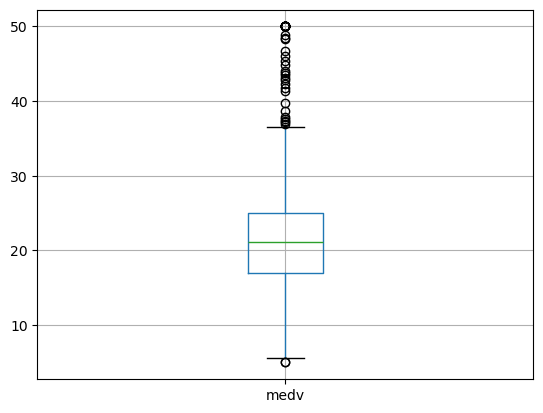

In [3]:
#data cleaning
#handle missing values 
df.isnull().sum()
#replacing null values with mean 
df.fillna(df.mean(),inplace=True)
#handle outliers
df.boxplot(column=['medv'])
#removing outliers  
Q1=df['medv'].quantile(0.25)
Q3=df['medv'].quantile(0.75)    
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['medv']>=lower_bound) & (df['medv']<=upper_bound)]


In [4]:
#predict price of boston housing dataset using linear regression
X=df[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','b','lstat']]
Y=df['medv']

In [5]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
reg=LinearRegression()
reg.fit(X_train,Y_train)

LinearRegression()

In [8]:
Y_pred=reg.predict(X_test)


In [9]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,Y_pred)
print("R2 Score (%):", r2*100)


R2 Score (%): 75.11382517925347


In [10]:
from sklearn.model_selection import cross_val_score
cross_val_score(reg,X,Y,cv=5)

array([0.63756971, 0.74723052, 0.50074029, 0.12497471, 0.23669078])

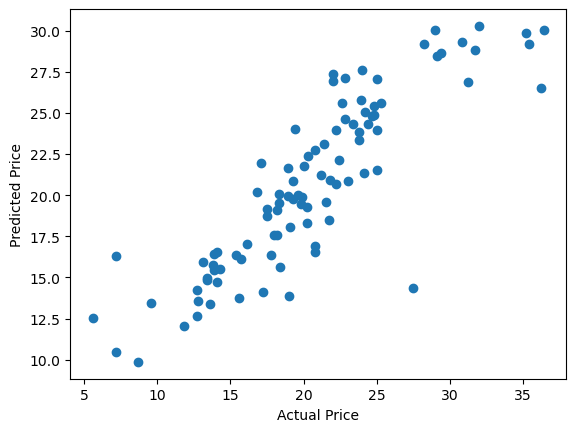

In [11]:
#correlation matrix
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")  
plt.ylabel("Predicted Price")
plt.show()


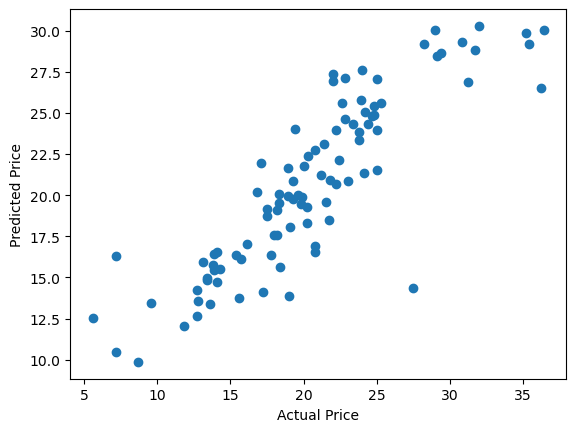

In [12]:
plt.scatter(Y_test, Y_pred)  
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()